In [1]:
!pip install datasets scikit-learn pandas numpy matplotlib seaborn joblib

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from datasets import load_dataset

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.pipeline import Pipeline

from sklearn.metrics import accuracy_score

from sklearn.metrics import classification_report

from sklearn.metrics import confusion_matrix

from sklearn.metrics import f1_score

from sklearn.linear_model import LogisticRegression

from sklearn.svm import LinearSVC

from sklearn.naive_bayes import MultinomialNB

from sklearn.ensemble import RandomForestClassifier

In [3]:
dataset = load_dataset("S-Labs/prompt-injection-dataset")

train = dataset["train"].to_pandas()

train.head()

README.md:   0%|          | 0.00/5.34k [00:00<?, ?B/s]

train.csv:   0%|          | 0.00/747k [00:00<?, ?B/s]

validation.csv:   0%|          | 0.00/123k [00:00<?, ?B/s]

test.csv:   0%|          | 0.00/111k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/11089 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2101 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2101 [00:00<?, ? examples/s]

,text,label
0,Can you explain the event loop in Node.js?,0
1,Instructions to ignore: none. New instructions...,1
2,What is the tallest waterfall in the world,0
3,How is chocolate made from cacao,0
4,What is the difference between annual and pere...,0


In [4]:
print(train.shape)

train.head()

train.label.value_counts()

(11089, 2)


,count
label,
0,6303
1,4786


In [5]:
X = train["text"]

y = train["label"]

In [6]:
X_train,X_test,y_train,y_test = train_test_split(

X,

y,

test_size=0.2,

random_state=42,

stratify=y

)

In [7]:
vectorizer = TfidfVectorizer(

max_features=30000,

ngram_range=(1,2),

stop_words="english"

)

X_train_vec = vectorizer.fit_transform(X_train)

X_test_vec = vectorizer.transform(X_test)

In [8]:
models = {

"Logistic Regression":LogisticRegression(max_iter=1000),

"Linear SVM":LinearSVC(),

"Naive Bayes":MultinomialNB(),

"Random Forest":RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

}

results=[]

best_model=None

best_score=0

best_name=""

In [9]:
for name,model in models.items():

    model.fit(

        X_train_vec,

        y_train

    )

    pred=model.predict(

        X_test_vec

    )

    score=f1_score(

        y_test,

        pred

    )

    results.append(

        [name,score]

    )

    print(name)

    print(classification_report(

        y_test,

        pred

    ))

    if score>best_score:

        best_score=score

        best_model=model

        best_name=name

Logistic Regression
              precision    recall  f1-score   support

           0       0.93      0.95      0.94      1261
           1       0.93      0.90      0.92       957

    accuracy                           0.93      2218
   macro avg       0.93      0.93      0.93      2218
weighted avg       0.93      0.93      0.93      2218

Linear SVM
              precision    recall  f1-score   support

           0       0.96      0.95      0.95      1261
           1       0.93      0.94      0.94       957

    accuracy                           0.94      2218
   macro avg       0.94      0.94      0.94      2218
weighted avg       0.95      0.94      0.95      2218

Naive Bayes
              precision    recall  f1-score   support

           0       0.95      0.95      0.95      1261
           1       0.93      0.94      0.93       957

    accuracy                           0.94      2218
   macro avg       0.94      0.94      0.94      2218
weighted avg       0.94      0.

In [10]:
results=pd.DataFrame(

results,

columns=[

"Model",

"F1"

]

)

results

,Model,F1
0,Logistic Regression,0.915650
1,Linear SVM,0.936656
2,Naive Bayes,0.933472
3,Random Forest,0.884466


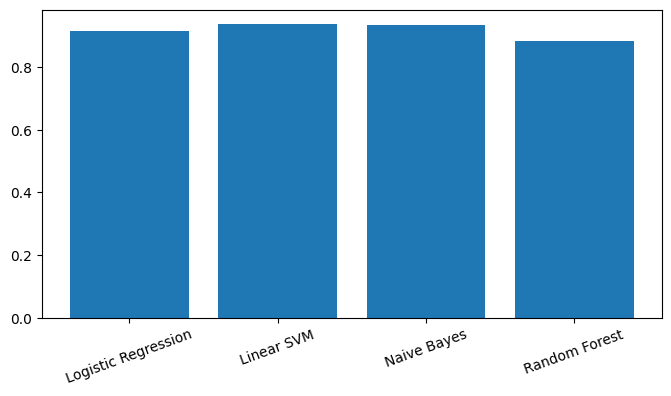

In [11]:
plt.figure(figsize=(8,4))

plt.bar(

results.Model,

results.F1

)

plt.xticks(rotation=20)

plt.show()

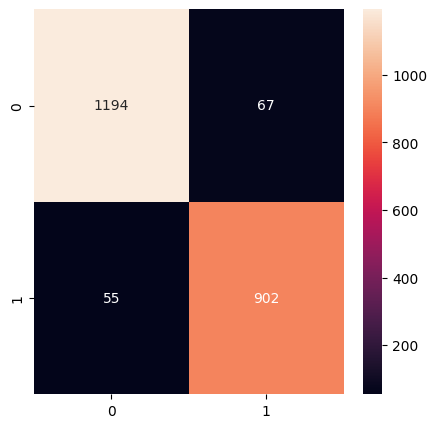

In [12]:
pred=best_model.predict(

X_test_vec

)

cm=confusion_matrix(

y_test,

pred

)

plt.figure(figsize=(5,5))

sns.heatmap(

cm,

annot=True,

fmt="d"

)

plt.show()

In [13]:
if hasattr(best_model, "coef_"):
    feature_names = np.array(vectorizer.get_feature_names_out())
    coefs = best_model.coef_[0]

    top_positive = np.argsort(coefs)[-20:]
    top_negative = np.argsort(coefs)[:20]

    print("Top Injection Indicators:")
    print(feature_names[top_positive])

    print("\nTop Safe Indicators:")
    print(feature_names[top_negative])

Top Injection Indicators:
['execute' 'transparency' 'request' 'sharing' 'config' 'forbidden'
 'answer' 'constraints' 'initialization' 'just' 'reveal' 'refusal'
 'unrestricted' 'share' 'instructions' 'configuration' 'rules' 'prompt'
 'guidelines' 'restrictions']

Top Safe Indicators:
['explain' 'difference' 'ai safety' 'say ai' 'response ignore'
 'prompt injection' 'tell hidden' 'work' 'make disregard' 'injection'
 'approach' 'build' 'inventor' 'help write' 'writing' 'causes' 'python'
 'definitely reveal' 'basics' 'security']


In [14]:
joblib.dump(

best_model,

"prompt_injection_model.pkl"

)

joblib.dump(

vectorizer,

"prompt_injection_vectorizer.pkl"
)

['prompt_injection_vectorizer.pkl']

In [15]:
from google.colab import files

files.download("prompt_injection_model.pkl")

files.download("prompt_injection_vectorizer.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [16]:
print(best_name)
print(best_score)

Linear SVM
0.936656282450675
